# 1. 데이터 이해 (Data Understanding)

본 프로젝트는 신용카드 거래 데이터를 활용하여 이상 거래(Fraud) 여부를 예측하는 것을 목표로 한다.

## 1) 데이터 개요

- 사용 데이터: fraud.csv
- 데이터 크기: 491,134 rows × 22 columns
- 데이터 유형: 수치형 변수 중심의 정형 데이터

## 2) 데이터 구조 확인

- df.shape를 통해 데이터 크기 확인
- df.info()를 통해 변수 타입 및 결측치 여부 확인
- df.head()를 통해 데이터 샘플 확인

## 3) 분석 목적

- 거래 정보를 기반으로 사기 여부(0/1)를 예측하는 분류 모델 구축
- 사기 데이터 비율 확인 (불균형 데이터 여부 점검 필요)

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("fraud.csv")

df.shape



(491134, 22)

- fraud.csv 데이터를 불러온 후 데이터 전체 크기를 확인하였다.
- 총 491,134개의 거래 데이터와 22개의 변수로 구성되어 있다.
- 비교적 큰 규모의 거래 데이터를 포함하고 있어, 이후 모델 학습을 위한 기초 데이터로 활용 가능하다.

In [4]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,...,40.6747,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,...,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,...,42.2203,-83.3583,31515,Police officer,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,...,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0


- 상위 5개 데이터를 확인하여 각 변수의 실제 데이터 형태를 파악하였다.

- 거래 일시(trans_date_trans_time), 결제 금액(amt), 가맹점(merchant), 성별(gender) 등  
   다양한 거래 및 고객 정보가 포함되어 있음을   확인하였다.

- 타겟 변수인 is_fraud는 사기 여부를 나타내는 이진 변수(0: 정상, 1: 사기)임을 확인하였다.

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  491134 non-null  object 
 1   cc_num                 491134 non-null  int64  
 2   merchant               491134 non-null  object 
 3   category               491134 non-null  object 
 4   amt                    491134 non-null  float64
 5   first                  491134 non-null  object 
 6   last                   491134 non-null  object 
 7   gender                 491134 non-null  object 
 8   street                 491134 non-null  object 
 9   city                   491134 non-null  object 
 10  state                  491134 non-null  object 
 11  zip                    491134 non-null  int64  
 12  lat                    491134 non-null  float64
 13  long                   491134 non-null  float64
 14  city_pop               491134 non-nu

- 전체 데이터는 491,134개의 행과 22개의 열로 구성되어 있다.

- 모든 변수에서 결측치(Null 값)는 존재하지 않음을 확인하였다.

- 데이터 타입은 float64, int64, object가 혼합되어 있다.

- 날짜 변수(trans_date_trans_time, dob)는 현재 object 타입이므로,  
   이후 분석을 위해 datetime 타입으로 변환이 필요하다.


In [6]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,4.911340e+05,491134.000000,491134.000000,491134.000000,491134.000000,4.911340e+05,4.911340e+05,491134.000000,491134.000000,491134.000000
mean,3.706013e+17,69.050120,50770.532384,37.931230,-90.495619,1.213922e+05,1.358730e+09,37.930272,-90.495411,0.002533
std,1.260229e+18,160.322867,26854.947965,5.341193,12.990732,3.725751e+05,1.819402e+07,5.372986,13.004100,0.050264
min,5.038744e+11,1.000000,1843.000000,24.655700,-122.345600,4.600000e+01,1.325376e+09,23.655789,-123.345106,0.000000
25%,2.131124e+14,8.960000,28405.000000,33.746700,-97.235100,1.228000e+03,1.343087e+09,33.781388,-96.984814,0.000000
50%,3.531130e+15,42.170000,49628.000000,38.507200,-87.591700,5.760000e+03,1.357257e+09,38.545124,-87.573441,0.000000
75%,4.653879e+15,80.330000,75048.000000,41.520500,-80.731000,5.083500e+04,1.374626e+09,41.624294,-80.685567,0.000000
max,4.956829e+18,25086.940000,99323.000000,48.887800,-69.965600,2.906700e+06,1.388534e+09,49.887523,-68.965624,1.000000


- 수치형 변수의 기초 통계량을 확인하였다.
- 일부 변수(예: amt)는 최대값이 평균 대비 매우 커 이상치 존재 가능성이 있다.

# 2. 데이터 전처리

## 1) 불필요 변수 제거

In [7]:
df = df.drop(columns=['trans_num', 'first', 'last', 'street'])


## 2) 날짜 타입 변환

In [8]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])


- 사기 예측에 불필요한 식별 정보(trans_num, first, last, street)를 제거하였다.
- 날짜 관련 변수(trans_date_trans_time, dob)를 datetime 형식으로 변환하였다.
- 이후 시간 기반 파생변수 생성을 위한 전처리를 완료하였다.


# 3) 결측치 확인

In [9]:
df.isnull().sum()


trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
gender                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

각 변수별 결측치 개수를 확인하였다.  
확인 결과, 모든 컬럼에서 결측치가 존재하지 않는 것으로 나타났다.
따라서 별도의 결측치 처리 과정은 필요하지 않다.

# 4)이상치 탐지

In [10]:
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


In [11]:
len(df[(df['amt'] < lower) | (df['amt'] > upper)])


34800

- 거래 금액(amt) 변수에 대해 IQR(Interquartile Range) 방식을 활용하여 이상치를 탐지하였다.
- Q1(25%)와 Q3(75%)를 계산한 후 IQR = Q3 - Q1로 정의하였다.

이상치 기준은

- 하한: Q1 − 1.5 × IQR
- 상한: Q3 + 1.5 × IQR

그 결과, 총 34,800건의 이상치가 존재하는 것으로 확인되었다.  
고액 결제는 실제 사기 거래와 관련될 가능성이 있으므로, 단순 제거 대신 로그 변환 등 왜곡 완화 방법을 고려한다.

# 3. 파생 변수 생성 

In [12]:
df['log_amt'] = np.log1p(df['amt'])


In [13]:
df['hour'] = df['trans_date_trans_time'].dt.hour


In [14]:
df['weekday'] = df['trans_date_trans_time'].dt.weekday


In [15]:
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365


사기 거래 탐지를 위한 예측 성능 향상을 위해 새로운 변수를 생성하였다.

1. `log_amt`  
   - 거래 금액(`amt`)은 분포가 오른쪽으로 크게 치우쳐 있으므로  
     로그 변환을 통해 분포 왜곡을 완화하였다.

2. `hour`  
   - 거래 발생 시간(`trans_date_trans_time`)에서 시(hour) 정보를 추출하였다.  
   - 특정 시간대에 사기 거래가 집중될 가능성을 고려하였다.

3. `weekday`  
   - 거래 발생 요일 정보를 생성하였다.  
   - 평일/주말 또는 특정 요일 패턴을 반영하기 위함이다.

4. `age`  
   - 거래 시점과 생년월일(`dob`)을 활용하여 고객 나이를 계산하였다.  
   - 연령대에 따른 사기 거래 발생 차이를 반영할 수 있다.

기존 변수를 그대로 사용하는 것이 아니라,  
의미 있는 정보를 추출하여 모델이 학습하기 좋은 형태로 변환하였다.

# 4. EDA

## 1) 거래 금액과 사기 여부 분포

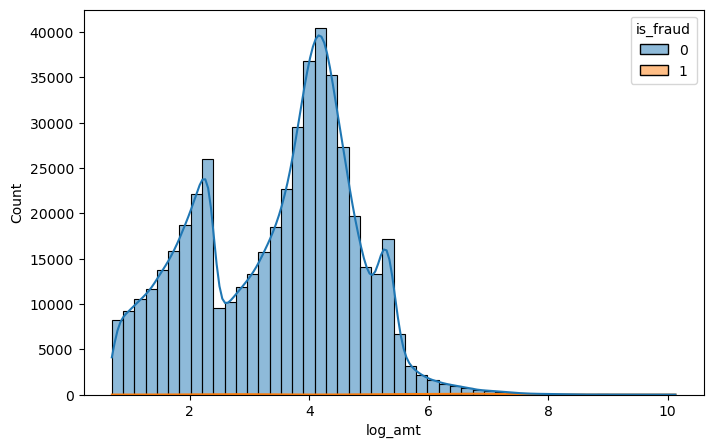

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='log_amt', hue='is_fraud', bins=50, kde=True)
plt.show()


- 일반 거래(0)는 log_amt 2~5 구간에 많이 분포

- 사기 거래(1)는 상대적으로 고액 구간(오른쪽) 에 더 많이 나타남

- 금액이 높을수록 사기 가능성이 증가하는 경향이 보임

> 따라서 amt 또는 log_amt는 중요한 예측 변수 후보

## 2) 요일별 사기 비율

In [17]:
df.groupby('weekday')['is_fraud'].mean()


weekday
0    0.002615
1    0.002451
2    0.002378
3    0.003121
4    0.002538
5    0.002534
6    0.002246
Name: is_fraud, dtype: float64

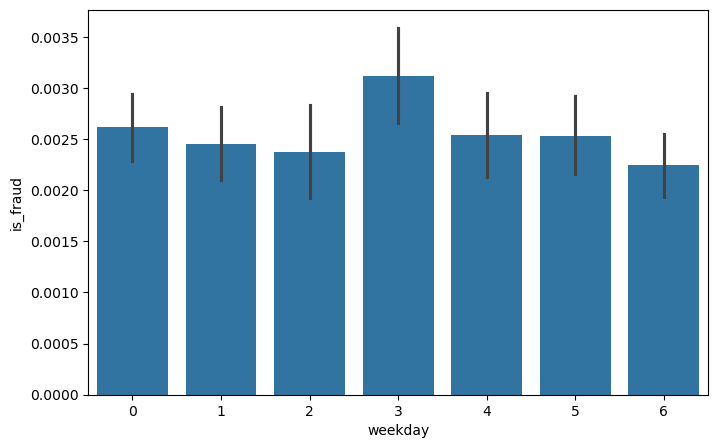

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x='weekday', y='is_fraud', data=df)
plt.show()


- 전반적으로 요일 간 사기 비율 차이는 크지 않다.
- 다만, weekday=3에서 상대적으로 높은 사기 비율이 관찰된다.
- 전체 사기 비율 자체가 매우 낮기 때문에(약 0.25% 수준),
  요일 변수 단독으로는 강한 설명력을 가지기 어려울 것으로 보인다.

## 3) 카테고리별 사기 비율

In [19]:
cat_fraud = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
cat_fraud


category
shopping_net      0.006177
grocery_pos       0.005056
misc_net          0.004329
shopping_pos      0.002772
gas_transport     0.002194
travel            0.001902
misc_pos          0.001759
food_dining       0.001723
kids_pets         0.001688
home              0.001661
personal_care     0.001633
entertainment     0.001576
health_fitness    0.001273
grocery_net       0.000327
Name: is_fraud, dtype: float64

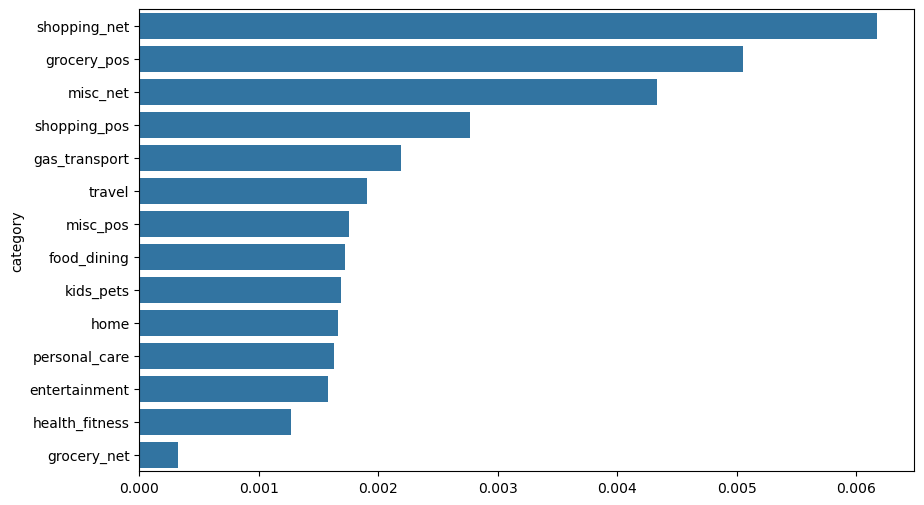

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x=cat_fraud.values, y=cat_fraud.index)
plt.show()


category별로 사기 거래 비율을 계산한 결과,  
**shopping_net, grocery_pos, misc_net** 등의 카테고리에서  
상대적으로 높은 사기 비율이 나타났다.

특히 online(쇼핑_net) 관련 거래에서 사기 발생 비율이 가장 높게 나타났으며,  
이는 비대면 거래 환경이 사기에 더 취약할 가능성을 시사한다.

→ category 변수는 사기 탐지 모델에서 중요한 설명 변수로 활용될 수 있다.


## 4).나이분석

In [21]:
df.groupby('age')['is_fraud'].mean().sort_values(ascending=False).head(10)


age
21    0.006468
38    0.006285
24    0.004545
19    0.004094
29    0.004075
15    0.003626
44    0.003286
46    0.002956
45    0.002834
16    0.002815
Name: is_fraud, dtype: float64

In [22]:
df['age_group'] = pd.cut(df['age'], bins=[0,20,30,40,50,60,70,100])
df.groupby('age_group')['is_fraud'].mean()


C:\Users\TG\AppData\Local\Temp\ipykernel_9140\1336926958.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['is_fraud'].mean()


age_group
(0, 20]      0.002243
(20, 30]     0.002948
(30, 40]     0.002397
(40, 50]     0.002394
(50, 60]          NaN
(60, 70]          NaN
(70, 100]         NaN
Name: is_fraud, dtype: float64

개별 나이 기준으로 사기 비율을 확인한 결과, 일부 특정 나이(예: 21세, 38세 등)에서 상대적으로 높은 사기 비율이 나타났다.

다만, 단일 나이 기준 분석은 표본 수에 따라 변동성이 클 수 있으므로, 연령대를 구간으로 나누어 추가 분석을 진행하였다.

연령대를 구간화하여 확인한 결과:

20~30대 구간에서 비교적 높은 사기 비율이 나타남  
30~50대 구간은 비교적 유사한 수준을 보임  
50대 이상 구간은 데이터 수가 부족하여 NaN이 발생함  
이는 실제 거래 데이터에서 고령층 데이터가 충분하지 않기 때문으로 보인다.  
따라서 연령 변수는 연속형(age) 과 구간형(age_group) 두 가지 형태 모두 모델링에 활용 가능성이 있다.

## 5) 시간대별 사기 비율


In [23]:
df.groupby('hour')['is_fraud'].mean()


hour
0     0.011446
1     0.010837
2     0.012185
3     0.013010
4     0.001232
5     0.001479
6     0.000702
7     0.001727
8     0.001214
9     0.000951
10    0.000958
11    0.000613
12    0.000238
13    0.000544
14    0.000137
15    0.000236
16    0.000338
17    0.000136
18    0.000305
19    0.000411
20    0.000445
21    0.000374
22    0.008846
23    0.008121
Name: is_fraud, dtype: float64

시간대(hour)별 사기 비율을 확인한 결과,
0~3시 및 22~23시 구간에서 상대적으로 높은 사기 비율이 나타났다.

반면, 10~18시 등 일반적인 주간 시간대에서는 사기 비율이 낮은 편이었다.

이는 심야 시간대에 비정상 거래가 집중될 가능성을 시사한다.
→ hour 변수는 사기 탐지 모델에서 유의미한 설명 변수로 활용될 수 있다.


## 상관관계 분석

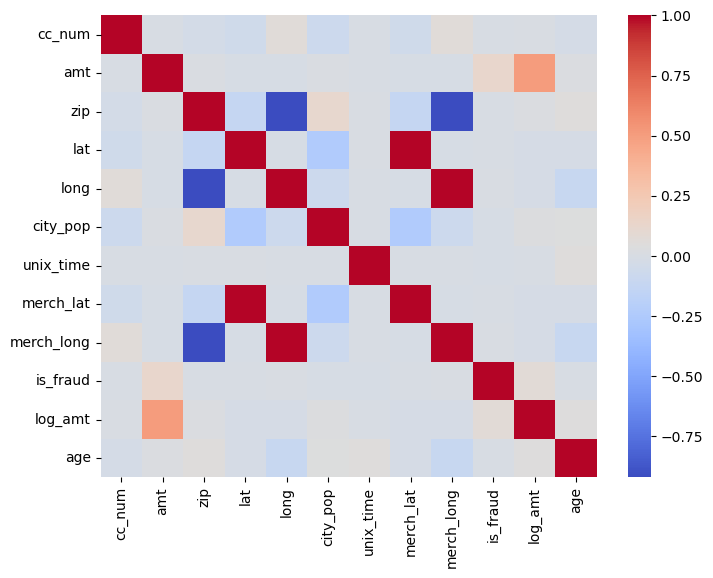

In [24]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.show()


수치형 변수 간 상관관계를 확인한 결과,
amt와 log_amt는 강한 양의 상관관계를 보였다.

위도(lat)와 가맹점 위도(merch_lat), 경도(long)와 가맹점 경도(merch_long) 역시
높은 상관관계를 나타냈다.

반면, is_fraud와 다른 변수들 간의 선형 상관계수는 전반적으로 크지 않았다.
이는 사기 여부가 단일 수치 변수와의 단순 선형 관계로 설명되기 어렵다는 것을 의미한다.

→ 따라서 단순 상관계수보다 비선형 패턴이나 변수 조합을 고려한 모델링이 필요하다.

## 지역별 분석 

In [25]:
df.groupby('state')['is_fraud'].mean().sort_values(ascending=False).head()


state
SD    0.004372
WY    0.003843
ME    0.003658
KY    0.003614
GA    0.003566
Name: is_fraud, dtype: float64

state별 사기 거래 비율을 확인한 결과,
SD, WY, ME, KY, GA 등의 주에서 상대적으로 높은 사기 비율이 나타났다.

그러나 전체 사기 비율 자체가 매우 낮은 수준(약 0.2~0.4%)이기 때문에
지역 변수만으로 사기를 설명하기는 어렵다.

→ state 변수는 단독 변수보다는 다른 변수들과 함께 사용할 때
보조적 설명 변수로 활용 가능하다.


## 클래스 불균형 확인 

In [26]:
df['is_fraud'].mean()


np.float64(0.0025329136243876418)

전체 거래 중 사기 거래 비율은 약 0.2~0.3% 수준으로 매우 낮다.

이는 정상 거래가 압도적으로 많은
심각한 클래스 불균형(Class Imbalance) 데이터임을 의미한다.


In [27]:
df['is_fraud'].value_counts()


is_fraud
0    489890
1      1244
Name: count, dtype: int64

정상 거래(0)가 대부분을 차지하며,
사기 거래(1)는 극히 일부에 불과하다.

→ 단순 Accuracy는 높은 값이 나올 수 있으나,
실제 모델 성능 평가는 Precision, Recall, F1-score 중심으로
확인해야 한다.


1. 금액은 사기 여부와 가장 관련성이 높은 변수로 보인다.  
   고액 거래일수록 사기 발생 비율이 증가하는 경향이 관찰되었다.

2. 거래 시간은 새벽 시간대에 상대적으로 높은 사기 비율이 나타났다.  
   시간 변수는 중요한 예측 변수 후보이다.

3. 거래 카테고리 중 shopping_net, grocery_pos, misc_net 등에서  
   비교적 높은 사기 비율이 관찰되었다.  
   특히 온라인 관련 거래는 사기에 더 취약한 것으로 보인다.

4. 요일과 지역은 차이가 존재하지만,  
   단독 변수로는 설명력이 크지 않을 가능성이 있다.

5. 전체 데이터는 극심한 클래스 불균형 구조를 가지므로,  
   향후 모델링 단계에서 불균형 처리 기법이 필요하다.


# 5.모델링

In [28]:
from sklearn.model_selection import train_test_split

X = df[['log_amt','hour','weekday','age','city_pop','lat','long','merch_lat','merch_long']]
y = df['is_fraud']


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
y_pred = model.predict(X_test)


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

confusion_matrix(y_test, y_pred)


Accuracy : 0.9974548749325541
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


array([[97977,     1],
       [  249,     0]])

## Baseline Logistic Regression 결과

- Accuracy는 99% 이상으로 매우 높게 나타났다.
- 그러나 Precision, Recall, F1-score는 모두 0으로 나타났다.
- 이는 모델이 사기 거래(1)를 전혀 예측하지 못했음을 의미한다.

Confusion Matrix 결과:
- 사기 거래를 단 한 건도 맞추지 못함
- 대부분을 정상 거래(0)로 예측

→ 극심한 클래스 불균형 문제로 인해 Accuracy가 왜곡됨을 확인하였다.


In [33]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')


In [34]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
confusion_matrix(y_test, y_pred)


Accuracy : 0.7158113349690004
Precision: 0.006175924603741253
Recall   : 0.6947791164658634
F1-score : 0.012243020416828846


c:\Users\TG\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([[70139, 27839],
       [   76,   173]])

## Class Weight 적용 Logistic Regression 결과

- Accuracy는 71.5%로 감소하였다.
- Recall은 69%로 크게 상승하여, 실제 사기 거래를 상당 부분 탐지하였다.
- 그러나 Precision이 0.6% 수준으로 매우 낮아, 정상 거래를 대량으로 사기로 오분류하였다.

Confusion Matrix 결과:
- 실제 사기 249건 중 173건 탐지 (Recall 개선)
- 하지만 정상 거래 27,839건을 사기로 잘못 예측

→ 클래스 불균형을 완화하자 Recall은 개선되었으나,
   False Positive가 급증하는 문제가 발생하였다.


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

confusion_matrix(y_test, y_pred)


Accuracy : 0.7400002036100054
Precision: 0.006940653513218435
Recall   : 0.714859437751004
F1-score : 0.013747827765977988


array([[72510, 25468],
       [   71,   178]])

## StandardScaler 적용 Logistic Regression 결과

- Accuracy는 74.0%로 소폭 증가하였다.
- Recall은 71.4%로 유지되어, 실제 사기 거래의 상당 부분을 탐지하였다.
- 그러나 Precision은 0.69%로 매우 낮게 나타나, 정상 거래를 대량으로 사기로 오분류하였다.

## Confusion Matrix 결과

- 실제 사기 249건 중 178건을 탐지하였다.
- 정상 거래 97,978건 중 25,468건을 사기로 잘못 예측하였다.

 → 클래스 불균형 문제로 인해 Recall은 높게 유지되었으나,
False Positive가 여전히 과도하게 발생하는 문제가 존재한다.

ROC-AUC : 0.7896946130272176


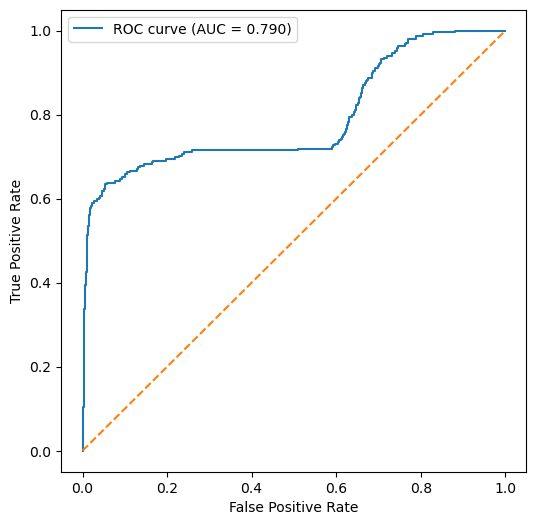

In [38]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_scaled)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC :", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="ROC curve (AUC = %.3f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [39]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0]
}).sort_values(by='coef', ascending=False)

coef_df.head(10)


,feature,coef
0,log_amt,0.961764
6,long,0.793651
7,merch_lat,0.425160
3,age,-0.019496
2,weekday,-0.029206
1,hour,-0.089919
4,city_pop,-0.263369
5,lat,-0.461875
8,merch_long,-0.734874


- log_amt가 가장 높은 양의 계수를 보이며, 고액 거래일수록 사기 확률이 증가하는 경향을 확인하였다.

- 위치 관련 변수(long, merch_lat) 역시 사기 확률에 영향을 미치는 것으로 나타났다.

- 반면, city_pop, lat, merch_long 등은 음의 계수를 보여 특정 지역 특성이 사기 발생 확률을 낮추는 방향으로 작용하였다.

→ 금액 및 지역적 요인이 사기 발생과 밀접하게 연관되어 있음을 확인하였다.

## 6. 비즈니스 인사이트

1. 고액 거래일수록 사기 발생 확률이 높게 나타났다.
   → 고액 거래에 대해 추가 인증 절차 강화 필요

2. 온라인 쇼핑 카테고리에서 사기 비율이 가장 높았다.
   → 온라인 결제 모니터링 강화 전략 필요

3. 특정 시간대(새벽)에 사기 비율이 상대적으로 높았다.
   → 심야 거래에 대한 이상 탐지 기준 강화 가능

4. 요일 변수는 단독 설명력은 낮지만, 다른 변수와 결합 시 의미를 가질 수 있다.

5. 모델 ROC-AUC는 약 0.79로,
   무작위 예측(0.5) 대비 유의미한 분류 성능을 보였다.
